The runner to see different Y_values:

In [1]:
import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.ticker import ScalarFormatter


import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



In [2]:
# Core imports man
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import time


# Numerical libraries
from scipy.integrate import solve_ivp, odeint, cumulative_trapezoid
from scipy.interpolate import (
    UnivariateSpline, splrep, splev, CubicSpline, 
    interp1d, PchipInterpolator, InterpolatedUnivariateSpline
)

import numdifftools as nd

# Random number generator (GSL)
import pygsl.rng

# custom InflationModels code to path the one below is for wkb approximation method
sys.path.append(
    '/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels'
)

#the path below assumes the original numerics from Deyan's code
# sys.path.append('/Users/epmeador/Desktop/InflationModels-master')

# Enable spectra
# SPECTRUM = True
SPECTRUM = True


# Local modules from InflationModels
from MacroDefinitions import *
from calcpath import *
from int_de import *
if SPECTRUM:
#     from spectrum_noS0_fixedNstar import * #this is mode modified one that I have been working with for wkb approx
#     from spectrum_OG import * #this is the original spectrum from full numerical code
#     from spectrum_pyoscode_tensor_clean import * #this is the spectrum from pyoscode 
#     from spectrum_pyoscode_scalar import * #this is the spectrum from pyoscode with scalar 
#     from spectrum_pyoscode_optimized_wkb import *
#     from spectrum_pyoscode_test_N import *

#was using below
#     from spectrum_OG_nanoscale_nodiagnostics import * #this is equivalent to the original spectrum from full numerical code w/o diagnostics

#am adding this because i wanna test out diff Y values
    import spectrum_OG_nanoscale_nodiagnostics as specmod

    derivs1 = specmod.derivs1
    scalarsys = specmod.scalarsys
    tensorsys = specmod.tensorsys
    spectrum = specmod.spectrum
    
    
# ========================
# SPECTRUM GRID SETTINGS
# ========================

Y_VALUES = [1, 3, 10, 50, 100]
BASELINE_Y = 50

k_file = "ks_eval_extend_target.dat"
ki_file = "ks_extend_target.dat"

knos = len(np.loadtxt(k_file))
kinos = len(np.loadtxt(ki_file))

print("Using spectrum grids:")
print("  k_file =", k_file, "knos =", knos)
print("  ki_file =", ki_file, "kinos =", kinos)

if SPECTRUM:
    specmod.k_file = k_file
    specmod.ki_file = ki_file
    specmod.knos = knos
    specmod.kinos = kinos
    specmod.Y = BASELINE_Y


# # ========================
# # GLOBAL SETTINGS
# # ========================
NEQS = 8
# SPECTRUM = True
# SPECTRUM = False

SAVEPATHS = True

NMAX = 0.97 #1.2
NMIN = 0.963 #0.3

#Test of Interest To Us

##For Higgs
LAM5_BASE = -8.92461e-9
LAM4_BASE = 6.87065e-08
LAM3_BASE = -4.60971e-6


# ##For non-Higgs
# LAM5_BASE = -2.794e-05
# LAM4_BASE = 6.3e-05
# LAM3_BASE = 1.06e-03



# ## Generic Spread
# # LAM5_DELTA = 1e-10
# # LAM5_MIN = LAM5_BASE - LAM5_DELTA   
# # LAM5_MAX = LAM5_BASE + LAM5_DELTA  

# # Narrow Range: 
# FRAC_WINDOW = 0.5   # or 0.3 for tighter
# LAM5_MIN = LAM5_BASE * (1 - FRAC_WINDOW)
# LAM5_MAX = LAM5_BASE * (1 + FRAC_WINDOW)

# # # Moderate Range: 
# # LAM5_MIN = -2.5e-8
# # LAM5_MAX = 2.5e-8

#Kinney Range:
#For neqs8 or lam5 variation I want to randomly pick in this lam5 range
LAM5_MIN = -5e-5
LAM5_MAX = 5e-5

#For neqs7 or lam4 variation I want to randomly pick in this lam4 range
LAM4_MIN = -5e-4
LAM4_MAX = 5e-4

LAM3_MIN = -5e-3
LAM3_MAX = 5e-3

#Tight range
# #For neqs8 or lam5 variation I want to randomly pick in this lam5 range
# FRAC_WINDOW = 0.5   # or 0.3 for tighter
# LAM5_MIN = LAM5_BASE * (1 - FRAC_WINDOW)
# LAM5_MAX = LAM5_BASE * (1 + FRAC_WINDOW)

# # #For neqs7 or lam4 variation I want to randomly pick in this lam4 range
# LAM4_MIN = LAM4_BASE * (1 - FRAC_WINDOW)
# LAM4_MAX = LAM4_BASE * (1 + FRAC_WINDOW)


NUM_LAM_GRID = 100
# NUM_SPECTRA_ = 35

# lam5_set = np.linspace(LAM5_MIN, LAM5_MAX, num=NUM_LAM5_GRID)
lam5_set = np.random.uniform(LAM5_MIN, LAM5_MAX, size=NUM_LAM_GRID) #Can cycle through randomly
lam5_set = np.sort(np.append(lam5_set, [LAM5_BASE]))
# # lam5_set = np.unique(lam5_set) 


lam4_set = np.random.uniform(LAM4_MIN, LAM4_MAX, size=NUM_LAM_GRID) #Can cycle through randomly
lam4_set = np.sort(np.append(lam4_set, [LAM4_BASE]))

lam3_set = np.random.uniform(LAM3_MIN, LAM3_MAX, size=NUM_LAM_GRID) #Can cycle through randomly
lam3_set = np.sort(np.append(lam3_set, [LAM3_BASE]))


#Short Range for Testing Convergence Order
#Set below is good for testing smallest number needs to be to match
# # lam5_set = [-8.92461e-09, 0, -8.92461e-08, -8.92461e-07, -8.92461e-06, -8.92461e-05, -8.92461e-10, -8.92461e-11, -8.92461e-12, -8.92461e-13, -8.92461e-14, -8.92461e-15, -8.92461e-16, -8.92461e-17, -8.92461e-18, -8.92461e-19, -8.92461e-20, -8.92461e-23, -8.92461e-26, -8.92461e-29, -8.92461e-32] 


# derivs1 = derivs ##added this for now
# print(f"Total models: {len(lam5_set)}")  # Should be 250 (or between 1-250)
# print(f"Base λ5={LAM5_BASE:.6e} included: {LAM5_BASE in lam5_set}")

#This sets how many nontrivial models you are running (interesting models you want)
NUMPOINTS = 1        # number of nontrivial models per λ5

#This will give us the min and max number of e-folds we are looking for
NUMEFOLDSMAX = 65.0
NUMEFOLDSMIN = 57.0

## Here we are writing out our output files we can name to analyze data

# BASE_OUTDIR = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6"
BASE_PATH_ROOT = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
BASE_OUTDIR = f"{BASE_PATH_ROOT}/neqs{NEQS}_Y_variation"
# RNG initialiation process
#This can be used to generate a random generator that works well with simulations

my_random = pygsl.rng.ranlxd2()
my_random.set(0)
np.random.seed(0)


#Here we define a class for several variables, this will initialize several variables
#The size we are setting for Y and initY is the same as NEQs which may be number of equations and is set in flow.py
#We set a state, the initial state, an empty string in the class, number of points, and e-folds

class Calc:
    def __init__(self):
        self.Y = np.zeros(NEQS, dtype=float, order='C')
        self.initY = np.zeros(NEQS, dtype=float, order='C')
        self.ret = ""
        self.npoints = 0
        self.Nefolds = 0.0

#Below we are initializing our starting slow roll parameter values
#We should be able to choose what ell we are extending to.

def pick_init_vals(lam3, lam4, lam5):

    init_vals = np.zeros(NEQS, dtype=float, order='C')

    init_vals[0] = 5.5/np.sqrt(8*np.pi)
    init_vals[1] = 1.0
    init_vals[2] = 0.000209237
    init_vals[3] = -0.0342419
    init_vals[4] = 0.000278972
    init_vals[5] = lam3
    init_vals[6] = lam4
    init_vals[7] = lam5

    init_Nefolds = 60
    return init_vals, init_Nefolds

# #For generic model
# def pick_init_vals(lam3, lam4, lam5):

#     #This is what is making it slow I think, uncomment init_vals below
#    # current higgs values
#     init_vals = np.zeros(NEQS, dtype=float, order='C')
#     init_vals[0] = 0 #phi0 #i dont think this really affects it??
#     init_vals[1] = 1.0 #H0
#     init_vals[2] = 7.3957755954e-03 #epsilon0
#     init_vals[3] = 6.9439539348e-02 #sigma0
#     init_vals[4] = 1.4308967742e-03 #2lam0
#     init_vals[5] = lam3 #1.0695001459e-03 #3lam
#     init_vals[6] = lam4 #6.3157423789e-05 #4lam
#     init_vals[7] = lam5
    
#     init_Nefolds = 60
#     return init_vals, init_Nefolds


# #SAVING PATHS
# #This next part of the code will print either asymptote or nontrivial 
# #And decides when to save the code 
# #This is based on what the model itself is doing

#This function below will calculation the spectrum computed from y
#As long as its in a particular range
#This is where I would limit my range of spectrum models of interest
#Otherwise it returns false

def we_should_calc_spec(y):
    return (specindex(y) > NMIN and specindex(y) < NMAX)

#Specifically, we will save a model with some interesting dynamics
#And this means either asymptote or nontrivial - for us nontrivial 
#Also only if the path has not been saved yet, and only for 
#Every nth successful model
#This governs path saving in the non-spectral case

def we_should_save_path(retval, save, pointcount, printevery):
    return (retval == "nontrivial") and (not save) and (pointcount % printevery == 0)

#Overall, this writes model trajectory to a file
#the SRP at each integration step, the number of N remaining, gives a reconstructed V, and e_H
    # Open output file

def save_path(y, N, kount, fname):
    with open(fname, "w") as outfile:
    # Output intermediate data from the integration
        for i in range(kount):
            for j in range(NEQS):
            #get y variable as a function of i in kount
            #should be like SRP as a function of time
            #j loops over NEQS which are used 
                outfile.write("%le " % y[j, i])
            outfile.write("%lf " % N[i])
            #Will also write out N at that time step
#             V = 3 * y[1, i]**2 * (1. - y[2, i]/3.) #this one is wrong, i think this is what he had
            V = (3./(8.*np.pi)) * y[1, i] * y[1, i] * (1.-y[2, i]/3.) #what the original code had, need 8pi
            outfile.write("%le %le\n" % (V, (V*y[2, i])/(3. - y[2, i]))) #I think this is KE


def run_neqs8_lam3_lam4_lam5_models(clean_output=True):
    import shutil

    TARGET_ACCEPTED = 1
    MAX_TRIALS = 100000

    summary_records = []

    if clean_output and os.path.exists(BASE_OUTDIR):
        print(f"Removing old output directory:\n{BASE_OUTDIR}")
        shutil.rmtree(BASE_OUTDIR)

    os.makedirs(BASE_OUTDIR, exist_ok=True)

    accepted_count = 0
    trial_count = 0

    rejected_asymptote = 0
    rejected_bad_ns = 0
    rejected_other = 0
    spectrum_error_count = 0
    duplicate_dir_count = 0

    while accepted_count < TARGET_ACCEPTED and trial_count < MAX_TRIALS:
        trial_count += 1

        # Force these two special cases first, then sample Kinney monster range
#         if trial_count == 1:
#             lam5 = LAM5_BASE
#         elif trial_count == 2:
#             lam5 = 0.0
#         else:
#             lam5 = np.random.uniform(LAM5_MIN, LAM5_MAX)
            
#         if trial_count == 1:
#             lam4 = LAM4_BASE
#             lam5 = LAM5_BASE
#         else:
#             lam4 = np.random.uniform(LAM4_MIN, LAM4_MAX)
#             lam5 = np.random.uniform(LAM5_MIN, LAM5_MAX)
            
            
        if trial_count == 1:
            lam3 = LAM3_BASE
            lam4 = LAM4_BASE
            lam5 = LAM5_BASE
        else:
            lam3 = np.random.uniform(LAM3_MIN, LAM3_MAX)
            lam4 = np.random.uniform(LAM4_MIN, LAM4_MAX)
            lam5 = np.random.uniform(LAM5_MIN, LAM5_MAX)

        print("\n" + "=" * 70)
        print(f"Trial {trial_count} | accepted {accepted_count}/{TARGET_ACCEPTED}")
#         print(f"Trying λ5 = {lam5:.10e}")
        print(f"Trying λ3 = {lam3:.10e}")
        print(f"Trying λ4 = {lam4:.10e}")
        print(f"Trying λ5 = {lam5:.10e}")

        calc = Calc()

#         yinit, calc.Nefolds = pick_init_vals(lam5)
        yinit, calc.Nefolds = pick_init_vals(lam3, lam4, lam5)        
        y = yinit.copy()

        path = np.array([[]])
        N = np.array([])

        t0 = time.perf_counter()
        calc.ret = calcpath(calc.Nefolds, y, path, N, calc)
        t1 = time.perf_counter()


        # ===== DEBUG N VALUES =====
        if calc.npoints > 5:  # safety check
            print("\nDEBUG N values:")
            print("  N[0]   =", N[0])
            print("  N[3]   =", N[3])
            print("  N[end] =", N[calc.npoints-1])
            print("  Nefolds (target) =", calc.Nefolds)
        else:
            print("WARNING: not enough N points to debug")
            
            
        print("\nDEBUG spectrum anchor:")
        print("  path eps at N[3]   =", path[2,3])
        print("  path sig at N[3]   =", path[3,3])
        print("  path xi  at N[3]   =", path[4,3])
        print("  y eps final        =", y[2])
        print("  y sig final        =", y[3])
        print("  y xi final         =", y[4])
        print("  path eps at N[end] =", path[2,calc.npoints-1])
        print("  path sig at N[end] =", path[3,calc.npoints-1])
        print("  path xi  at N[end] =", path[4,calc.npoints-1])

        print(f"calcpath runtime: {t1 - t0:.4f} s")
        print(f"calc.ret = {calc.ret}")

        if calc.ret == "asymptote":
            rejected_asymptote += 1
            print("REJECTED: asymptote")
            continue

        if calc.ret != "nontrivial":
            rejected_other += 1
            print(f"REJECTED: {calc.ret}")
            continue

        r = tsratio(y)
        ns = specindex(y)
        alpha_s = dspecindex(y)

        print("Candidate observables:")
        print(f"  r       = {r:.10e}")
        print(f"  ns      = {ns:.10f}")
        print(f"  alpha_s = {alpha_s:.10e}")

        if not (NMIN < ns < NMAX):
            rejected_bad_ns += 1
            print(f"REJECTED: ns={ns:.10f} outside ({NMIN}, {NMAX})")
            continue

        accepted_count += 1
        print("\n*** ACCEPTED MODEL ***")
        print(f"accepted #{accepted_count}")
        print(f"λ3 = {lam3:.10e}")
        print(f"λ4 = {lam4:.10e}")
        print(f"λ5 = {lam5:.10e}")
        print(f"ns = {ns:.10f}")

        OUTDIR = f"{BASE_OUTDIR}/lam5_{lam5:.10e}"
#         OUTDIR = f"{BASE_OUTDIR}/lam4_{lam4:.10e}_lam5_{lam5:.10e}" #I could change OUTDIR for clarity sake

        if os.path.exists(OUTDIR):
            duplicate_dir_count += 1
            OUTDIR = f"{BASE_OUTDIR}/lam5_{lam5:.10e}_trial_{trial_count:06d}"

        os.makedirs(OUTDIR, exist_ok=False)

        OUTFILE1_NAME = f"{OUTDIR}/test_nr_neqs{NEQS}.dat"
        OUTFILE2_NAME = f"{OUTDIR}/test_esigma_neqs{NEQS}.dat"

        with open(OUTFILE1_NAME, "w") as outfile1:
            outfile1.write(f"{r:.10f} {ns:.10f} {alpha_s:.10f}\n")

        with open(OUTFILE2_NAME, "w") as outfile2:
            for i in range(NEQS):
                outfile2.write("%le " % y[i])
            outfile2.write("%f\n" % calc.Nefolds)

        Y_VALUES = [1, 3, 10, 50, 100]

        if SPECTRUM:
            y_final = np.empty(NEQS + 1)

            if calc.npoints <= 3:
                print("WARNING: not enough path points for spectrum. Skipping spectrum.")
            else:
                y_final[:NEQS] = path[:NEQS, 3]
                y_final[NEQS] = N[3]

                for Yval in Y_VALUES:
                    print(f"Evaluating spectrum for Y = {Yval}...")

                    specmod.Y = Yval   # this changes the global Y inside spectrum module

                    u_s = np.empty((2, knos))
                    u_t = np.empty((2, knos))
                    
                    y_spec = y.copy()


                    t0 = time.perf_counter()
               
                    spectrum_status = specmod.spectrum(
                        y_final,
                        y_spec,
                        u_s,
                        u_t,
                        calc.Nefolds,
                        specmod.derivs1,
                        specmod.scalarsys,
                        specmod.tensorsys
                    )
                    
                    
                    t1 = time.perf_counter()
                    
                    if Yval == 50:
                        y[1] = y_spec[1]

                    print(f"spectrum runtime for Y={Yval}: {t1 - t0:.4f} s")

                    if spectrum_status:
                        spectrum_error_count += 1
                        print(f"WARNING: spectrum returned error/status flag for Y={Yval}.")

                    np.savetxt(f"{OUTDIR}/spec_s_neqs{NEQS}_Y{Yval}.dat", u_s[:, :knos].T)
                    np.savetxt(f"{OUTDIR}/spec_t_neqs{NEQS}_Y{Yval}.dat", u_t[:, :knos].T)
                    
                    
        if SPECTRUM:
            print(f"Before path normalization: y[1] = {y[1]:.6e}")

            for j in range(calc.npoints):
                path[0, j] = path[0, j] - path[0, calc.npoints - 1]
                path[1, j] = path[1, j] * y[1]

            print(f"After path normalization: max(path[1,:]) = {np.max(path[1,:]):.6e}")

        path_name = f"{OUTDIR}/path_neqs{NEQS}_lam5_{lam5:.10e}.dat"
        save_path(path, N, calc.npoints, path_name)
        
        print("\nDEBUG original calcpath end:")
        print("  original_end_index      =", getattr(calc, "original_end_index", None))
        print("  original_N_end          =", getattr(calc, "original_N_end", None))
        print("  original_N_before_end   =", getattr(calc, "original_N_before_end", None))
        print("  original_N_after_end    =", getattr(calc, "original_N_after_end", None))
        print("  original_eps_end        =", getattr(calc, "original_eps_end", None))
        print("  spectrum_N_start N[3]   =", N[3])
        print("  path_N_end N[-1]        =", N[calc.npoints-1])

        #Without native N path
#         summary_records.append({
#             "accepted_index": accepted_count,
#             "trial_index": trial_count,
#             "lam5": lam5,
#             "r": r,
#             "n_s": ns,
#             "alpha_s": alpha_s,
#             "Nefolds": calc.Nefolds,
#             "calc_ret": calc.ret,
#             "outdir": OUTDIR
#         })
        
    #With native N path
        summary_records.append({
            "accepted_index": accepted_count,
            "trial_index": trial_count,

            "lam3": lam3,
            "lam4": lam4,
            "lam5": lam5,

            "r": r,
            "n_s": ns,
            "alpha_s": alpha_s,
            "Nefolds": calc.Nefolds,

            "original_end_index": getattr(calc, "original_end_index", np.nan),
            "original_N_end": getattr(calc, "original_N_end", np.nan),
            "original_N_before_end": getattr(calc, "original_N_before_end", np.nan),
            "original_N_after_end": getattr(calc, "original_N_after_end", np.nan),
            "original_eps_end": getattr(calc, "original_eps_end", np.nan),

            "spectrum_N_start": N[3],
            "path_N_end": N[calc.npoints - 1],

            "calc_ret": calc.ret,
            "outdir": OUTDIR
        })
        

    summary_df = pd.DataFrame(summary_records)
    summary_file = f"{BASE_OUTDIR}/neqs{NEQS}_summary.csv"
    summary_df.to_csv(summary_file, index=False)

    print("\n" + "=" * 70)
    print("DONE")
    print(f"Accepted viable nontrivial models: {accepted_count}")
    print(f"Total trials: {trial_count}")
    print(f"Rejected asymptotes: {rejected_asymptote}")
    print(f"Rejected bad ns: {rejected_bad_ns}")
    print(f"Rejected other: {rejected_other}")
    print(f"Spectrum error count: {spectrum_error_count}")
    print(f"Duplicate directory count: {duplicate_dir_count}")
    print(f"Summary written to:\n{summary_file}")

    if accepted_count < TARGET_ACCEPTED:
        print(
            f"WARNING: only found {accepted_count}/{TARGET_ACCEPTED} accepted models "
            f"before hitting MAX_TRIALS={MAX_TRIALS}."
        )
        
        
%time run_neqs8_lam3_lam4_lam5_models()



Length of knos from ks_eval_extend 41
Length of kinos from ks_extend_target 41
Using spectrum grids:
  k_file = ks_eval_extend_target.dat knos = 41
  ki_file = ks_extend_target.dat kinos = 41
Removing old output directory:
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_Y_variation

Trial 1 | accepted 0/1
Trying λ3 = -4.6097100000e-06
Trying λ4 = 6.8706500000e-08
Trying λ5 = -8.9246100000e-09

DEBUG N values:
  N[0]   = 1.4076398454344598e-06
  N[3]   = 0.00015640763984543446
  N[end] = 60.0
  Nefolds (target) = 60

DEBUG spectrum anchor:
  path eps at N[3]   = 0.9992690237843788
  path sig at N[3]   = -6.671764787522471
  path xi  at N[3]   = 1.5978767414397141
  y eps final        = 0.00017064533550598327
  y sig final        = -0.030849698658804228
  y xi final         = 0.00022738766259612332
  path eps at N[end] = 0.00017064533550598327
  path sig at N[end] = -0.030849698658804228
  path xi  at 

To check those out:

In [3]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

def load_path_data(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}_Y_variation",
        f"{param_name}_{val_str}",
    )
    file_path = os.path.join(
        folder,
        f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
    )
    return pd.read_csv(file_path, sep=r"\s+", header=None).values

def folder_for(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    return os.path.join(
        base_path_root,
        f"neqs{NEQS}_Y_variation",
        f"{param_name}_{val_str}"
    )

def load_specs(NEQS, param_name, value):
    folder = folder_for(NEQS, param_name, value)

    s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt


    
def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]

def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref

def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref


def fractional_difference_on_overlap(x, y, x_ref, y_ref, frac_floor=1e-30):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac


def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}_Y_variation",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder



def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    base_path = f"{base_path_root}/neqs{NEQS}_Y_variation"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []

    for d in dirs:
        try:
            base = os.path.basename(d)
            val_str = base.replace(f"{param_name}_", "")
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    values.sort(key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")
        print(f"{'='*60}\n")

    return values

In [4]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    Yval=50,
    ns_min=0.955,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 22,
        "axes.titlesize": 20,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 15,
        "figure.titlesize": 24,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}_Y_variation", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}_Y{Yval}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}_Y{Yval}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])
        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            order = np.argsort(x)
            return x[order], y[order]

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if not (np.min(x) <= x_ref <= np.max(x)):
            raise ValueError(
                f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
            )

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at k_ref={x_ref}")

        return x, y / y_ref

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    def frac_on_base_grid(x_base, y_base, x_cmp, y_cmp, xmin=None, xmax=None):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xlo = max(np.min(x_base), np.min(x_cmp))
        xhi = min(np.max(x_base), np.max(x_cmp))

        if xmin is not None:
            xlo = max(xlo, xmin)

        if xmax is not None:
            xhi = min(xhi, xmax)

        mask = (x_base >= xlo) & (x_base <= xhi)

        x_use = x_base[mask]
        y_base_use = y_base[mask]

        if len(x_use) == 0:
            raise ValueError(
                f"No overlapping k-values in requested range [{xlo:.4e}, {xhi:.4e}]"
            )

        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)
        frac = (y_cmp_interp - y_base_use) / y_base_use

        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)
    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)
            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                xmin=k_min_scalar,
                xmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                xmin=None,
                xmax=None,
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}, Y={Yval}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}, Y={Yval}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Y value: {Yval}")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX",
                "ns",
                "delta_ns_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = scalar_k_mask(m["k_s"])

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.6)

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(rf"Scalar spectra: $P_s/P_s({k_ref})$, $Y={Yval}$")
    ax_pt.set_title(rf"Tensor spectra: $P_t/P_t({k_ref})$, $Y={Yval}$")
    ax_ps_err.set_title(rf"Scalar fractional error, $Y={Yval}$")
    ax_pt_err.set_title(rf"Tensor fractional error, $Y={Yval}$")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm base}$")
    ax_pt_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm base}$")

    xmin_scalar = (
        k_min_scalar if k_min_scalar is not None else np.min(k_s_base[mask_base_s])
    )
    xmax_scalar = (
        k_max_scalar if k_max_scalar is not None else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=15)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$), $Y={Yval}$",
        fontsize=24,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{scan_name}_filtered_ns_"
            f"{ns_min}_{ns_max}_Y{Yval}_"
            f"kmin{k_min_scalar}_kmax{k_max_scalar}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df


=== All models summary ===
Y value: 1
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


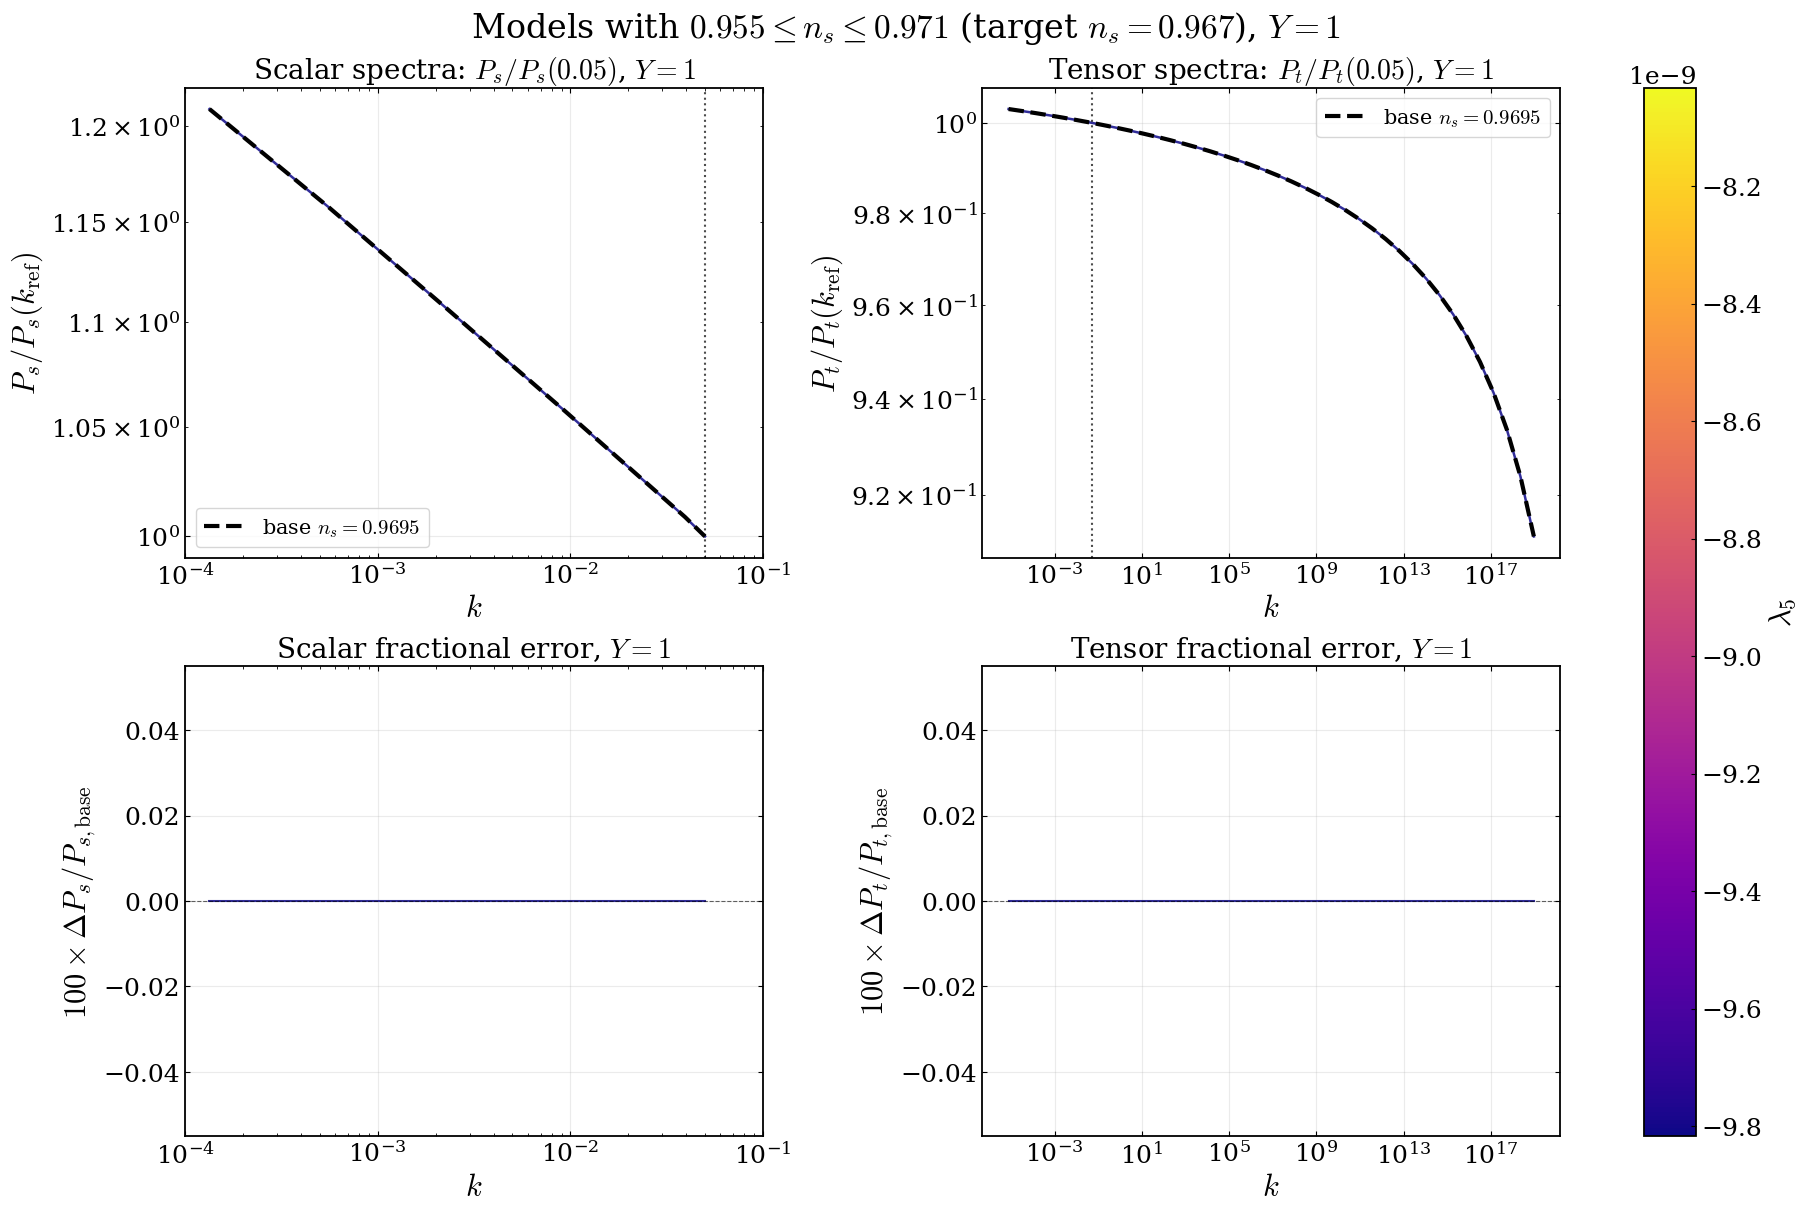


=== All models summary ===
Y value: 3
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


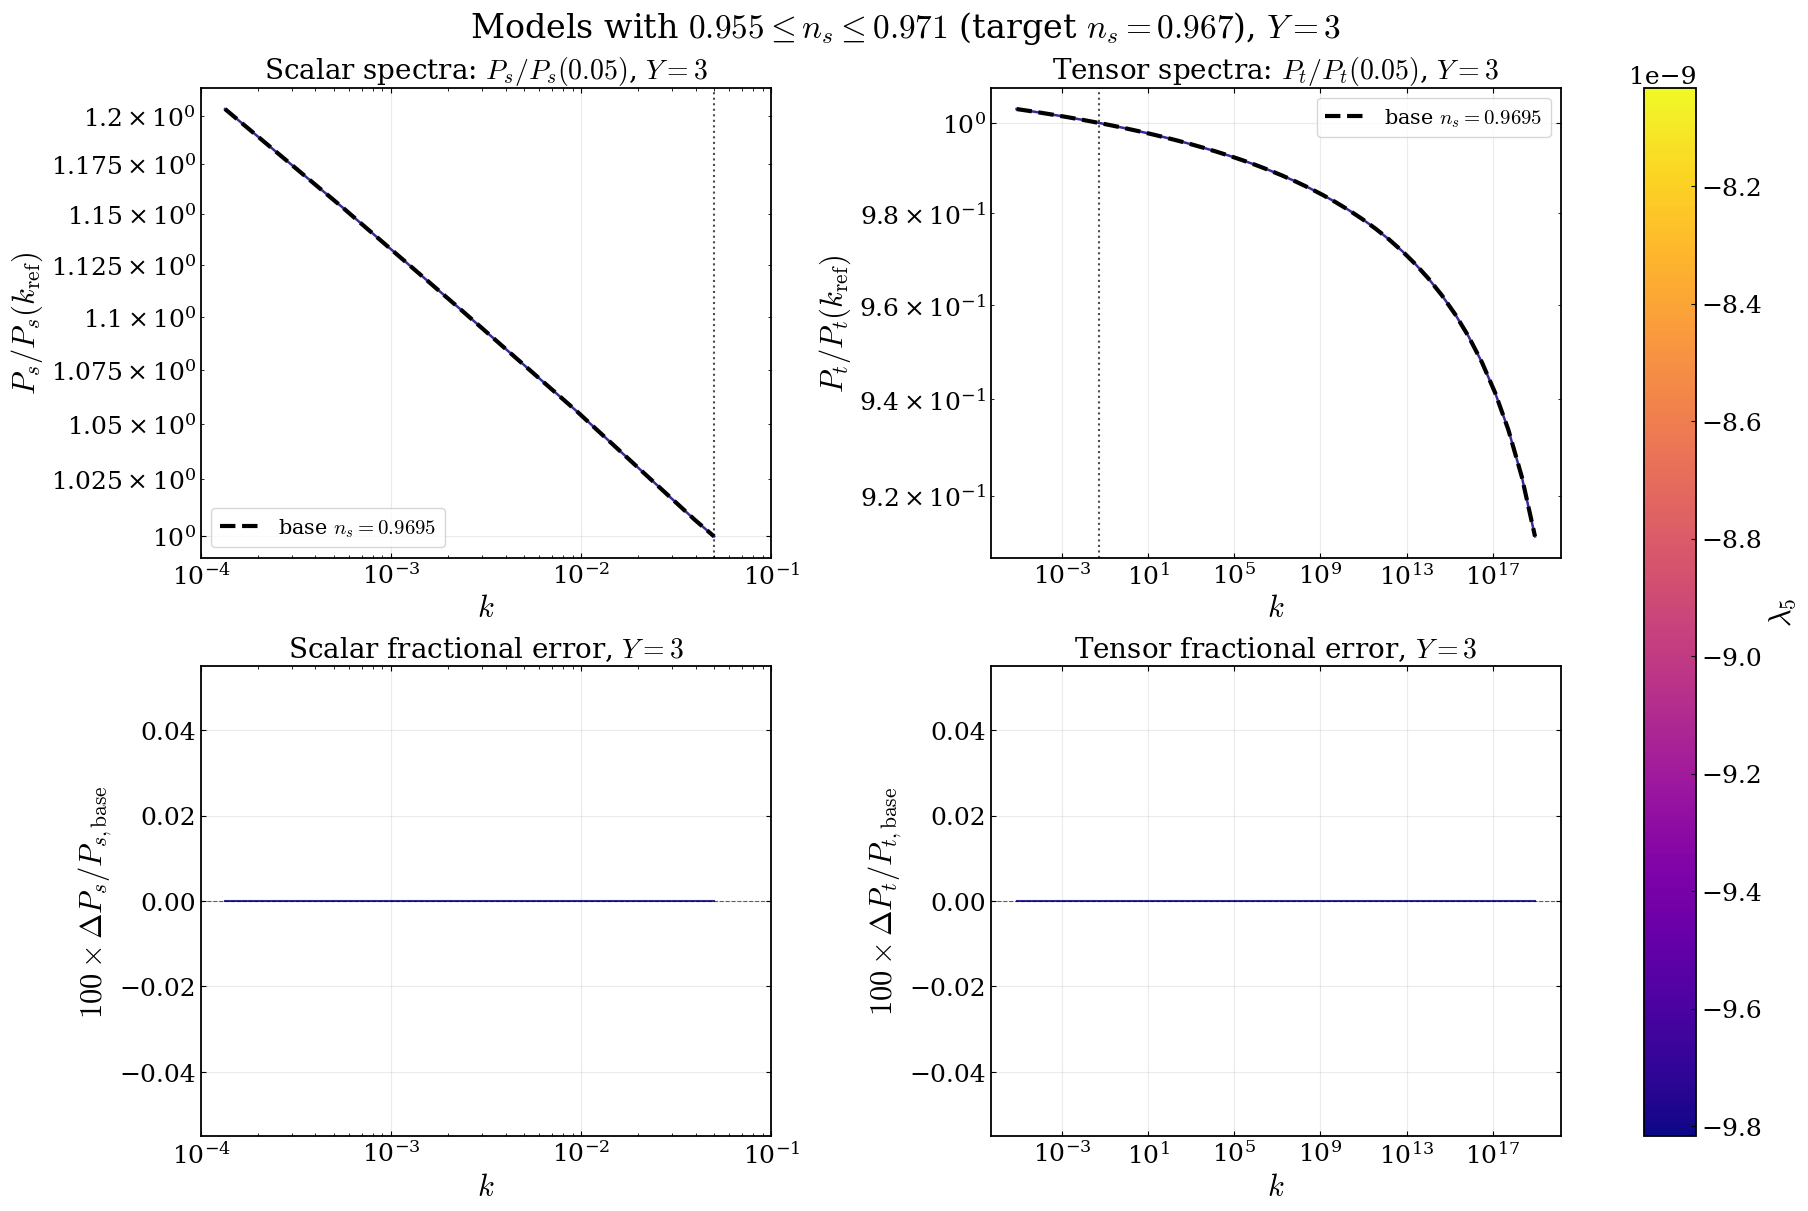


=== All models summary ===
Y value: 10
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


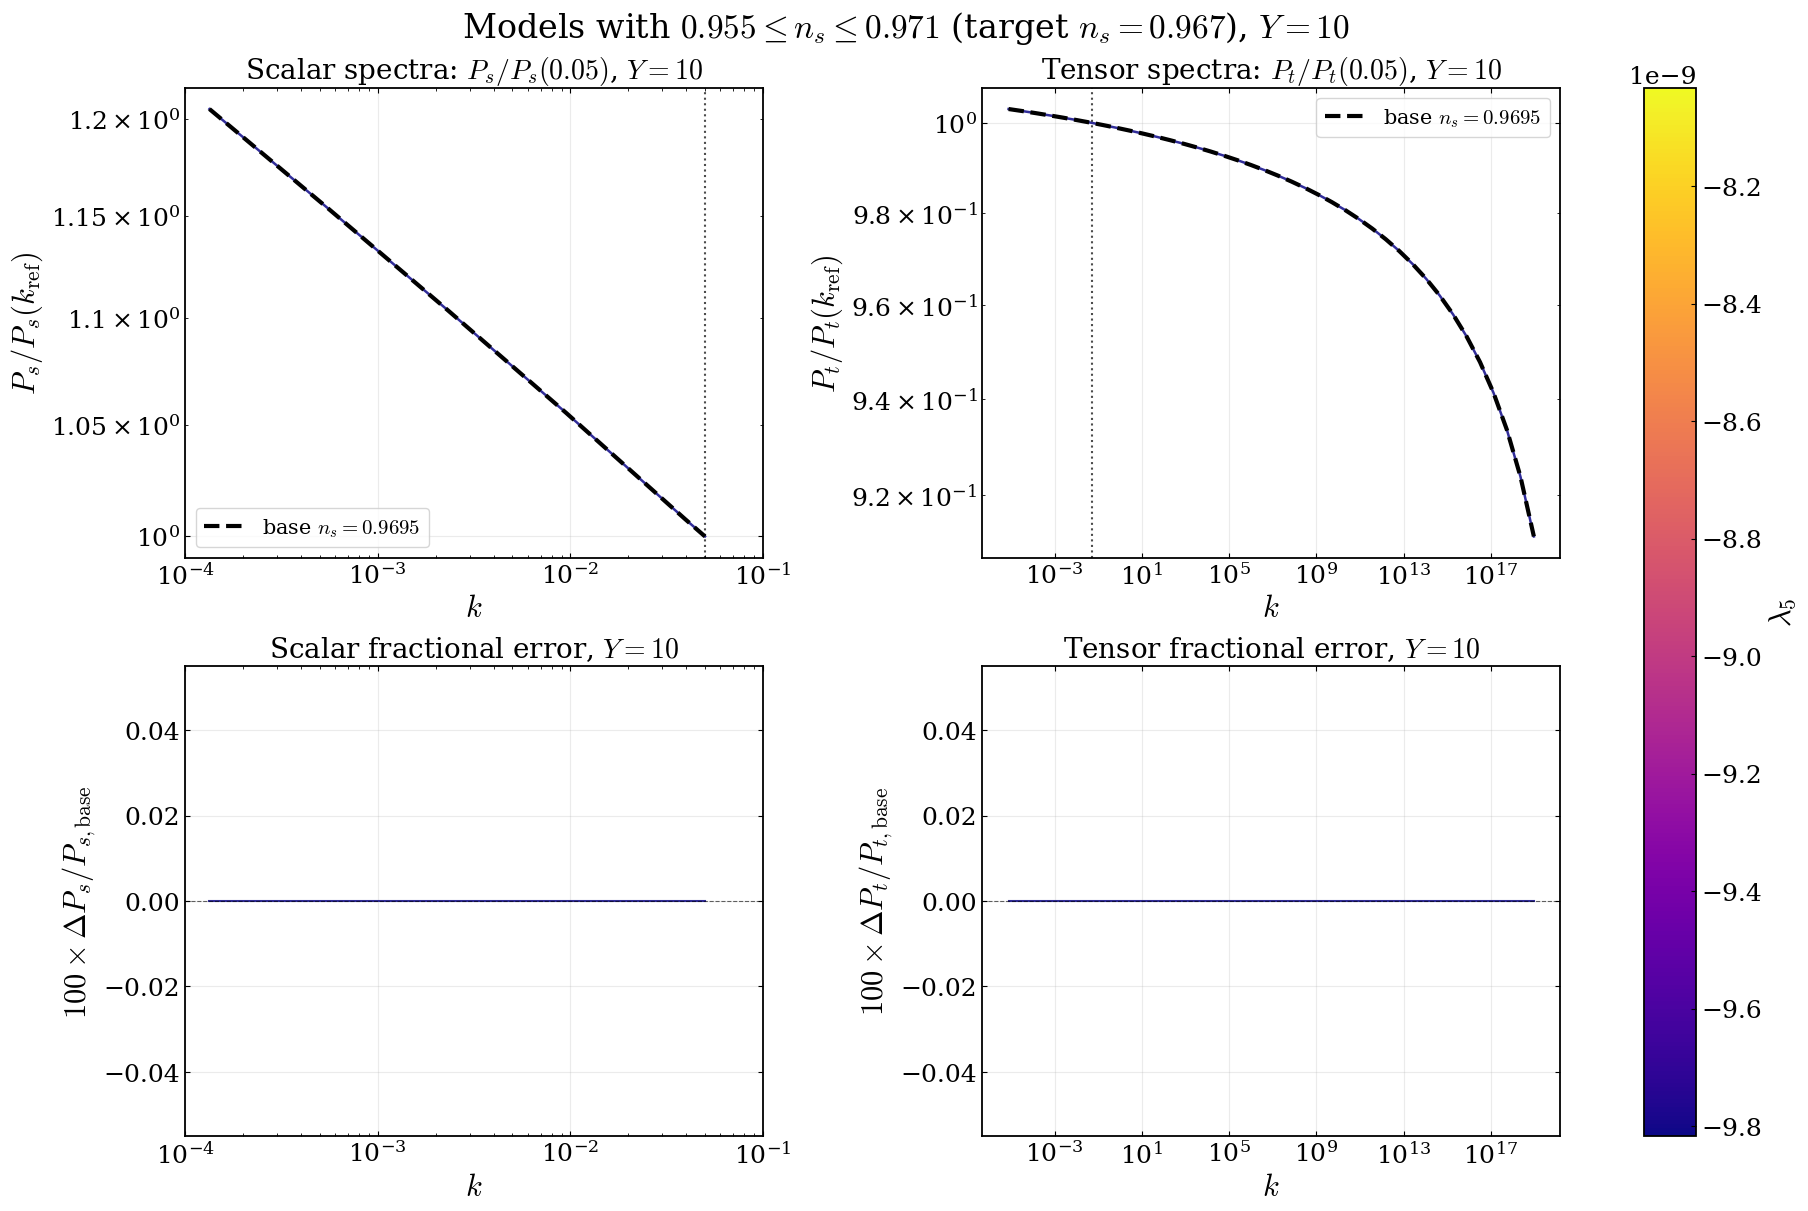


=== All models summary ===
Y value: 50
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


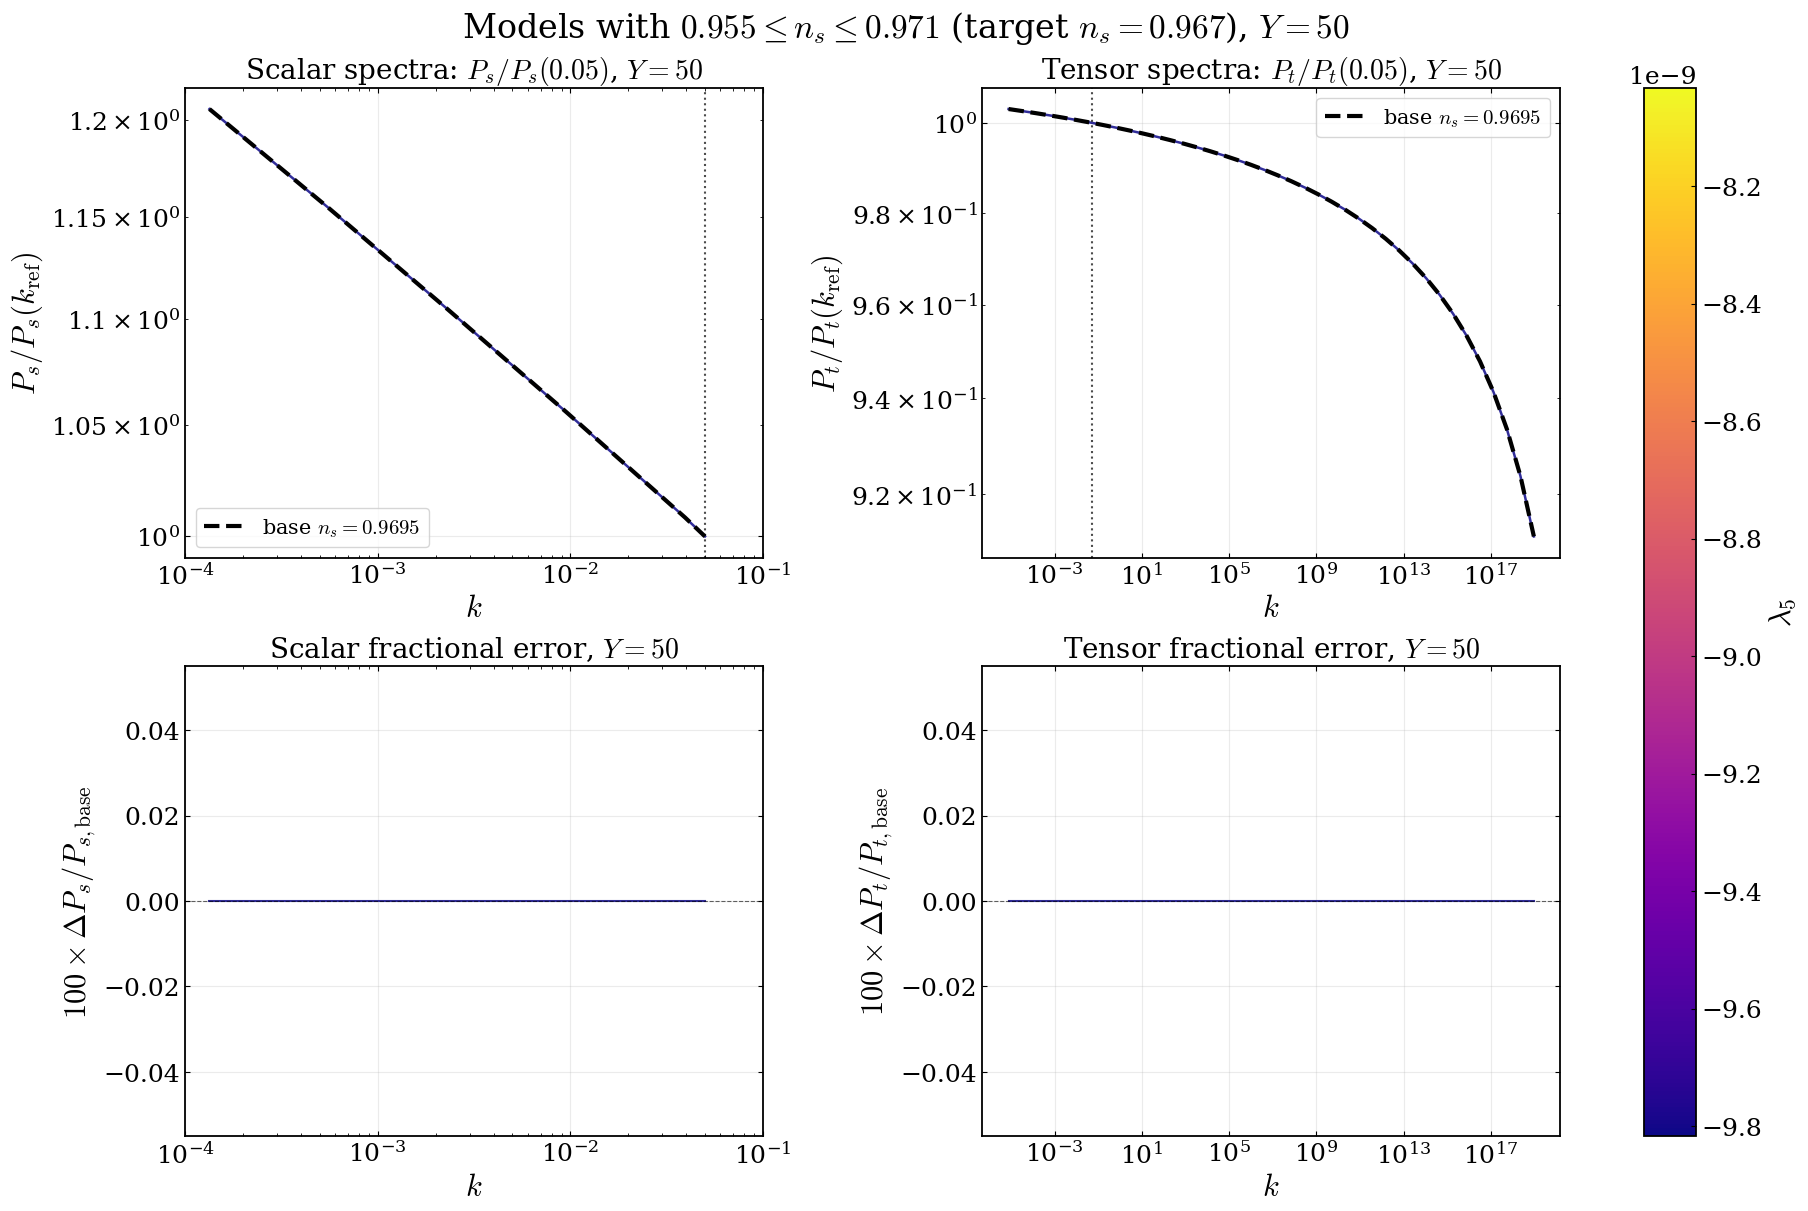


=== All models summary ===
Y value: 100
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


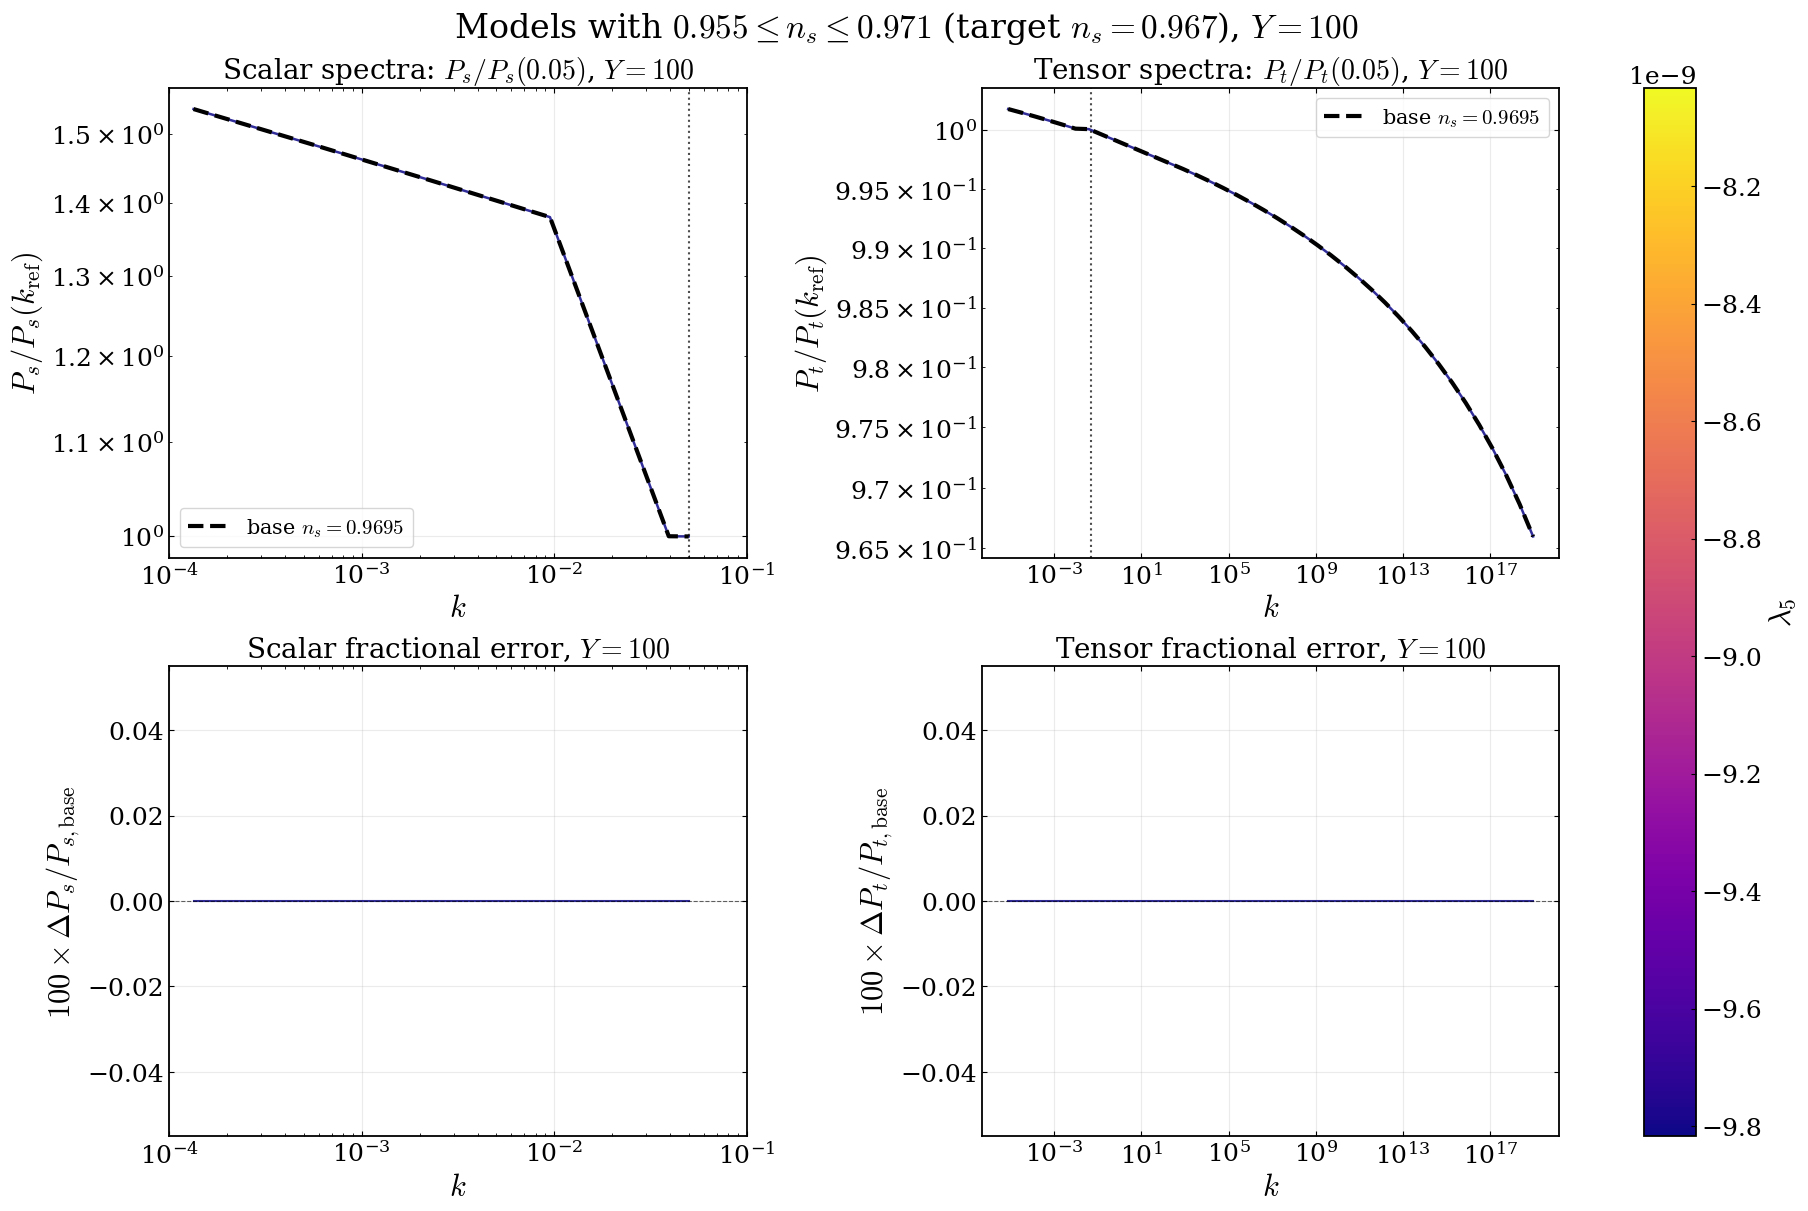

In [5]:
lam5_saved = [LAM5_BASE]

for Yval in [1, 3, 10, 50, 100]:
    stats, kept = plot_filtered_spectra_by_ns(
        NEQS=8,
        lamX_values=lam5_saved,
        baseX=LAM5_BASE,
        base_path_root=BASE_PATH_ROOT,
        Yval=Yval,
        k_min_scalar=1e-4,
        k_max_scalar=1e-1,
        show=True,
    )

Loading only accepted models

In [6]:
summary = pd.read_csv(f"{BASE_OUTDIR}/neqs{NEQS}_summary.csv")
lam5_saved = summary["lam5"].values


=== All models summary ===
Y value: 1
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


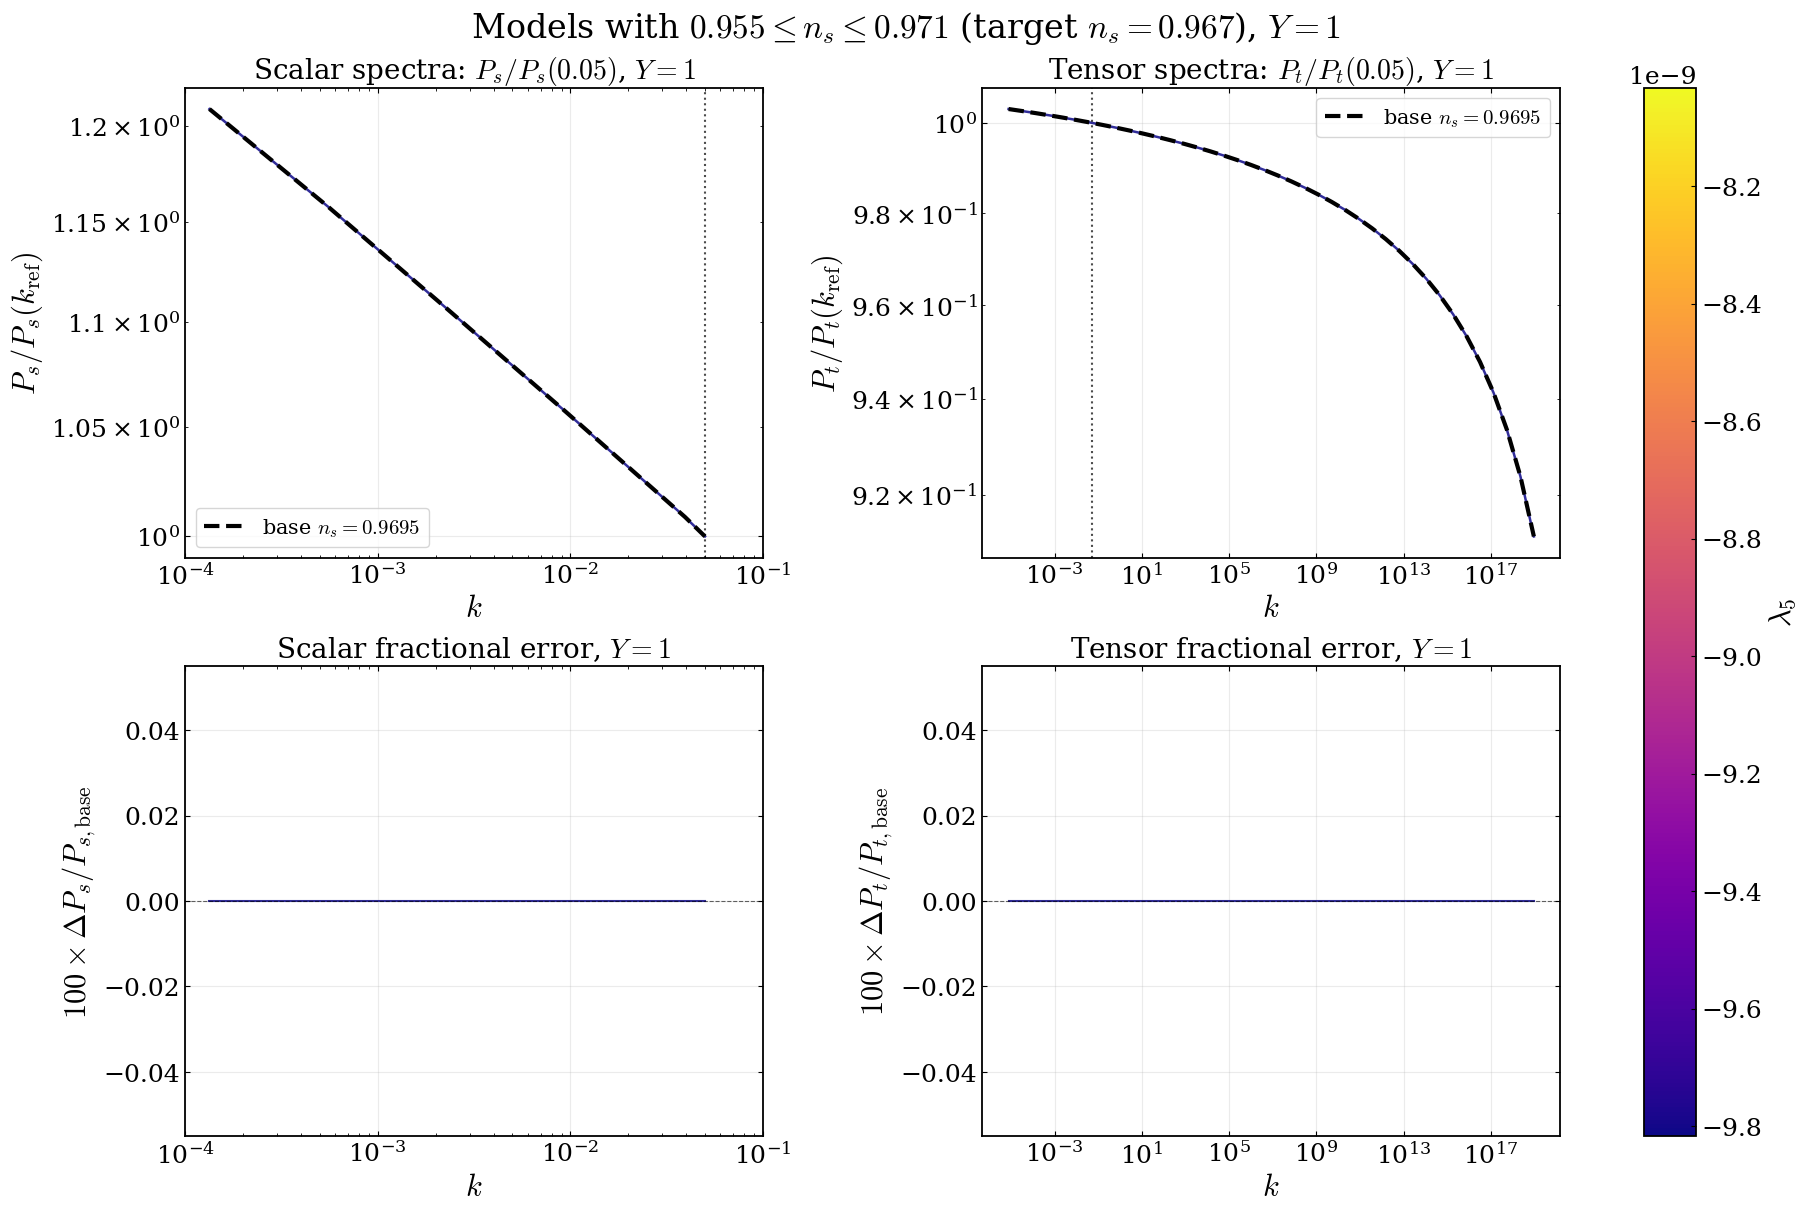


=== All models summary ===
Y value: 3
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


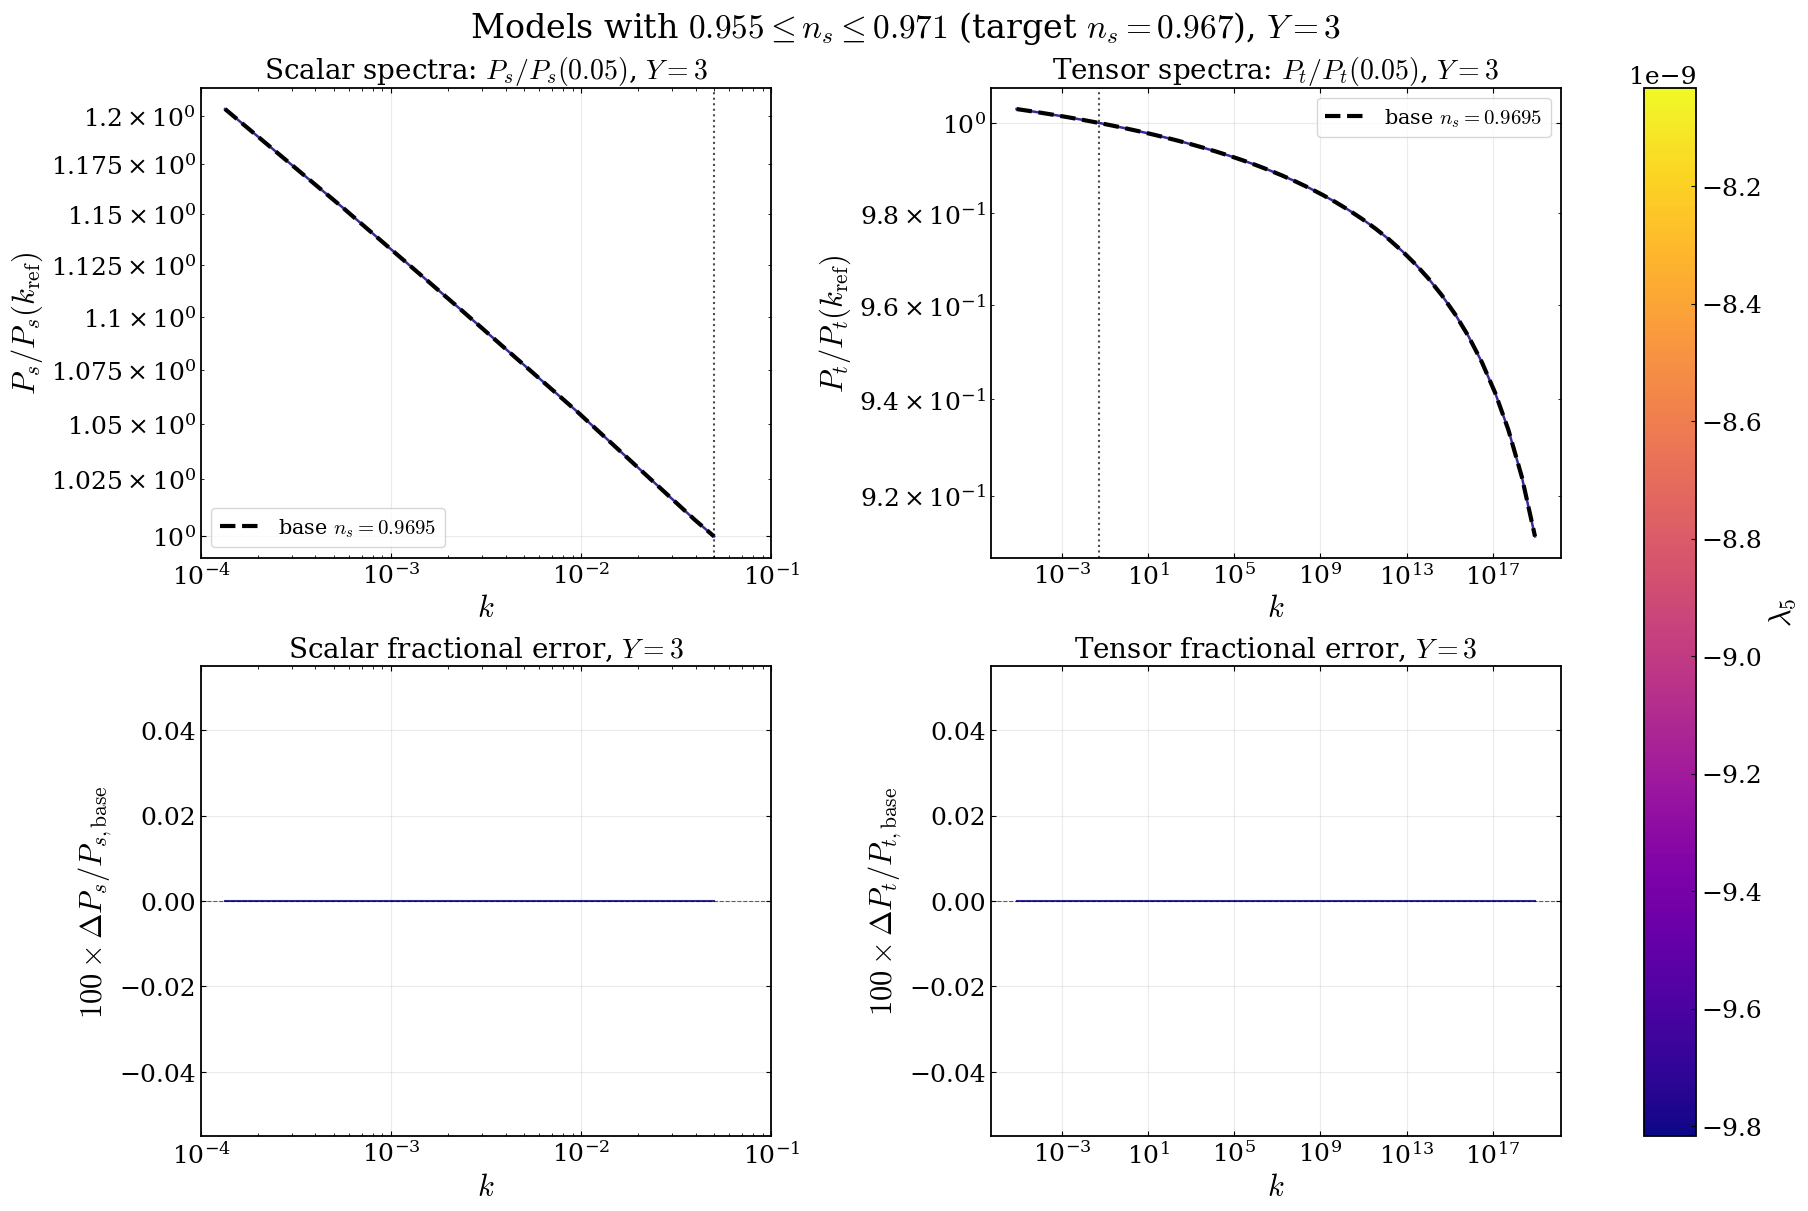


=== All models summary ===
Y value: 10
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


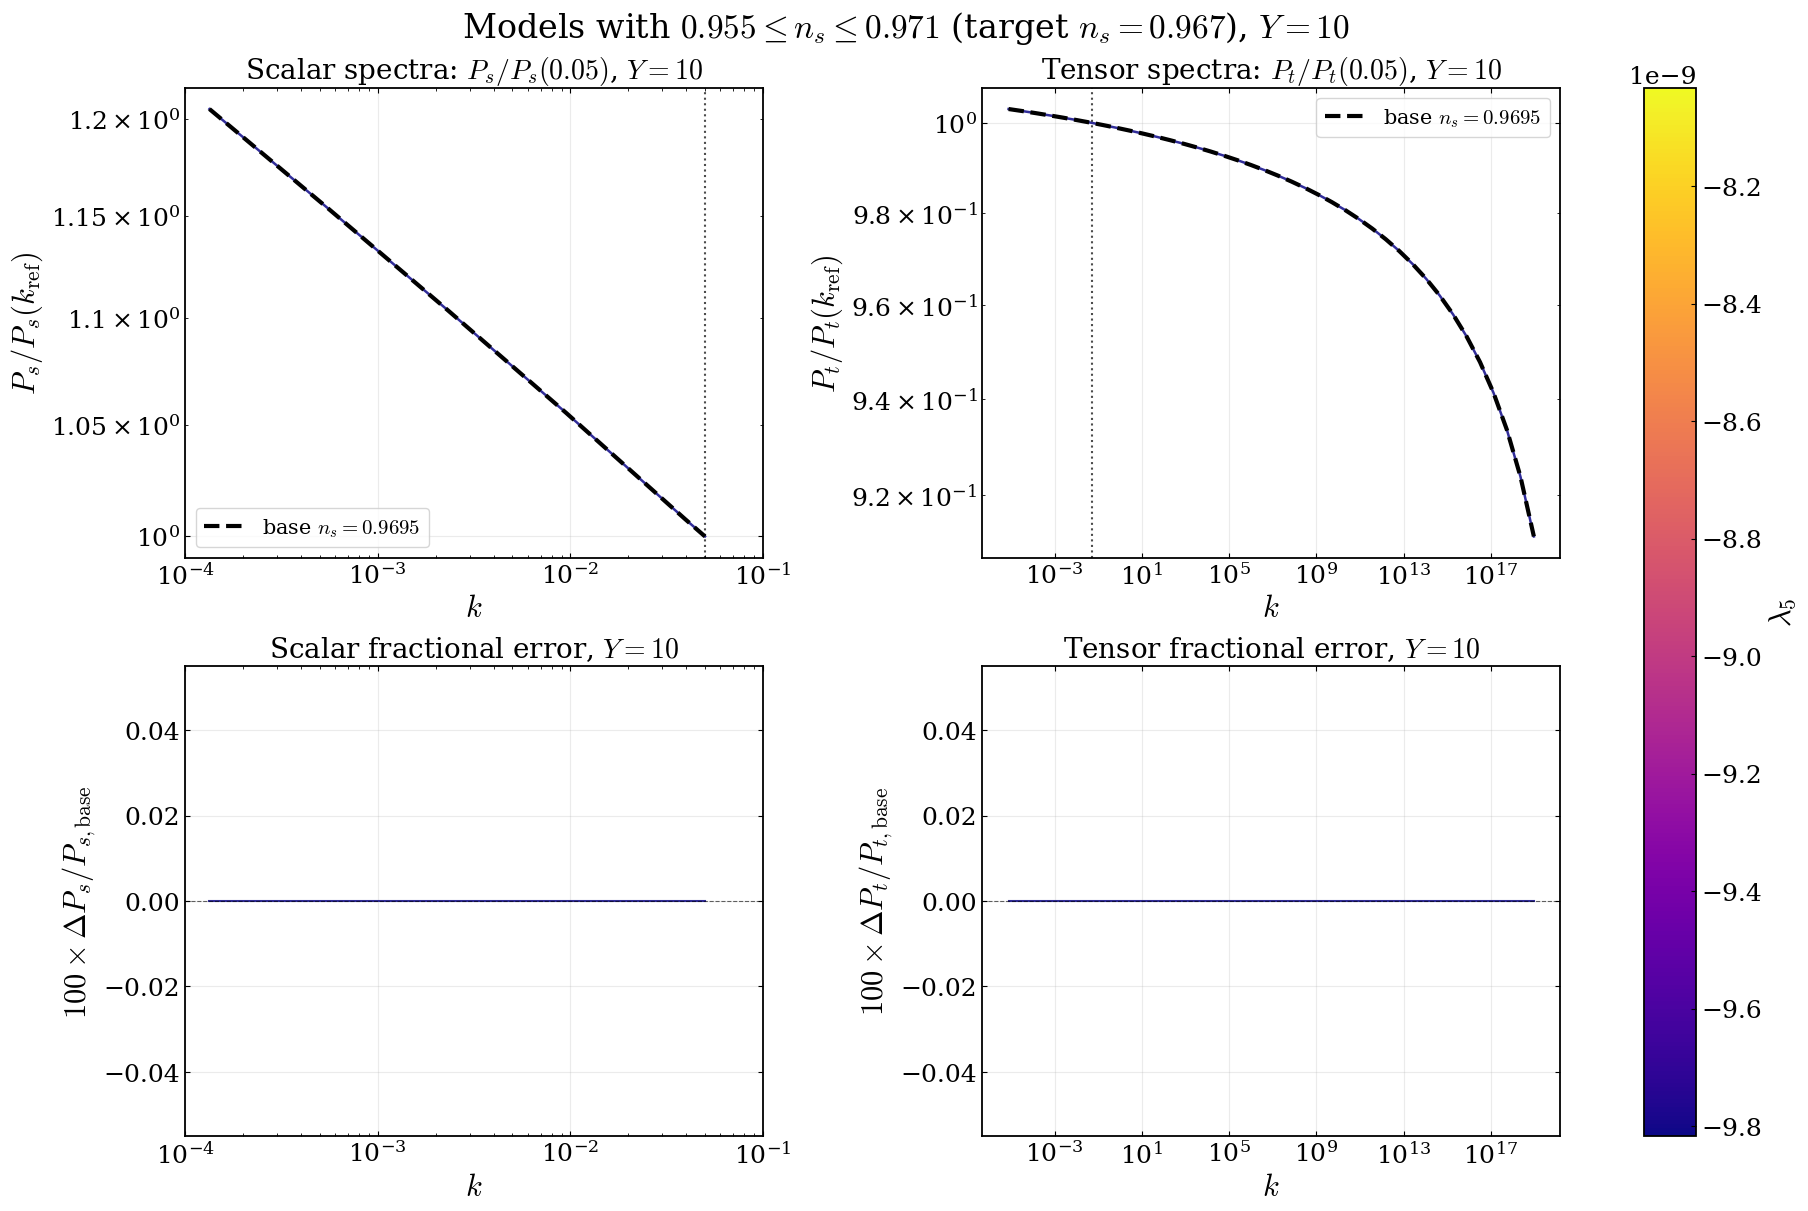


=== All models summary ===
Y value: 50
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


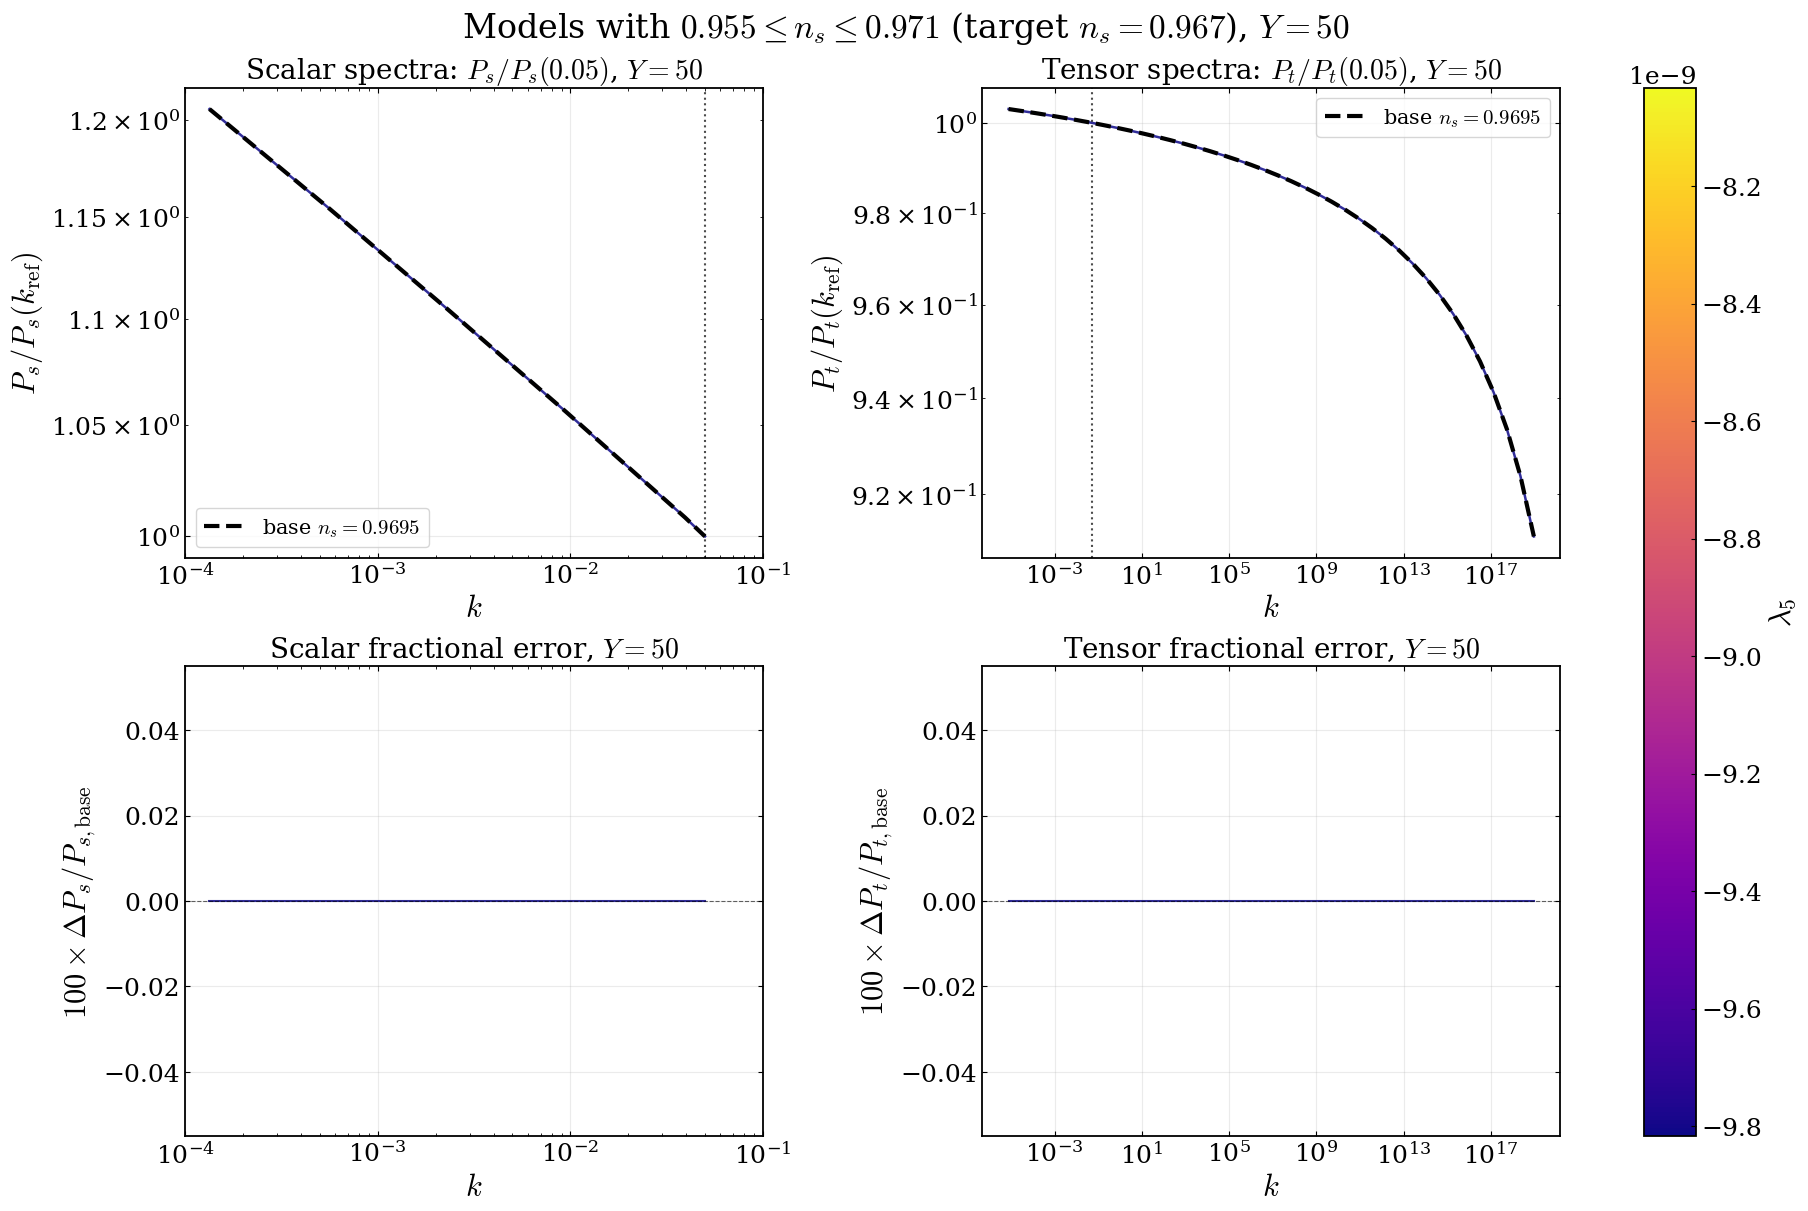


=== All models summary ===
Y value: 100
Total loaded: 1
Base ns: 0.969485
Models in ns window [0.955, 0.971]: 1

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.924610e-09 0.969485                 0.0           0.0          0.0           0.0          0.0


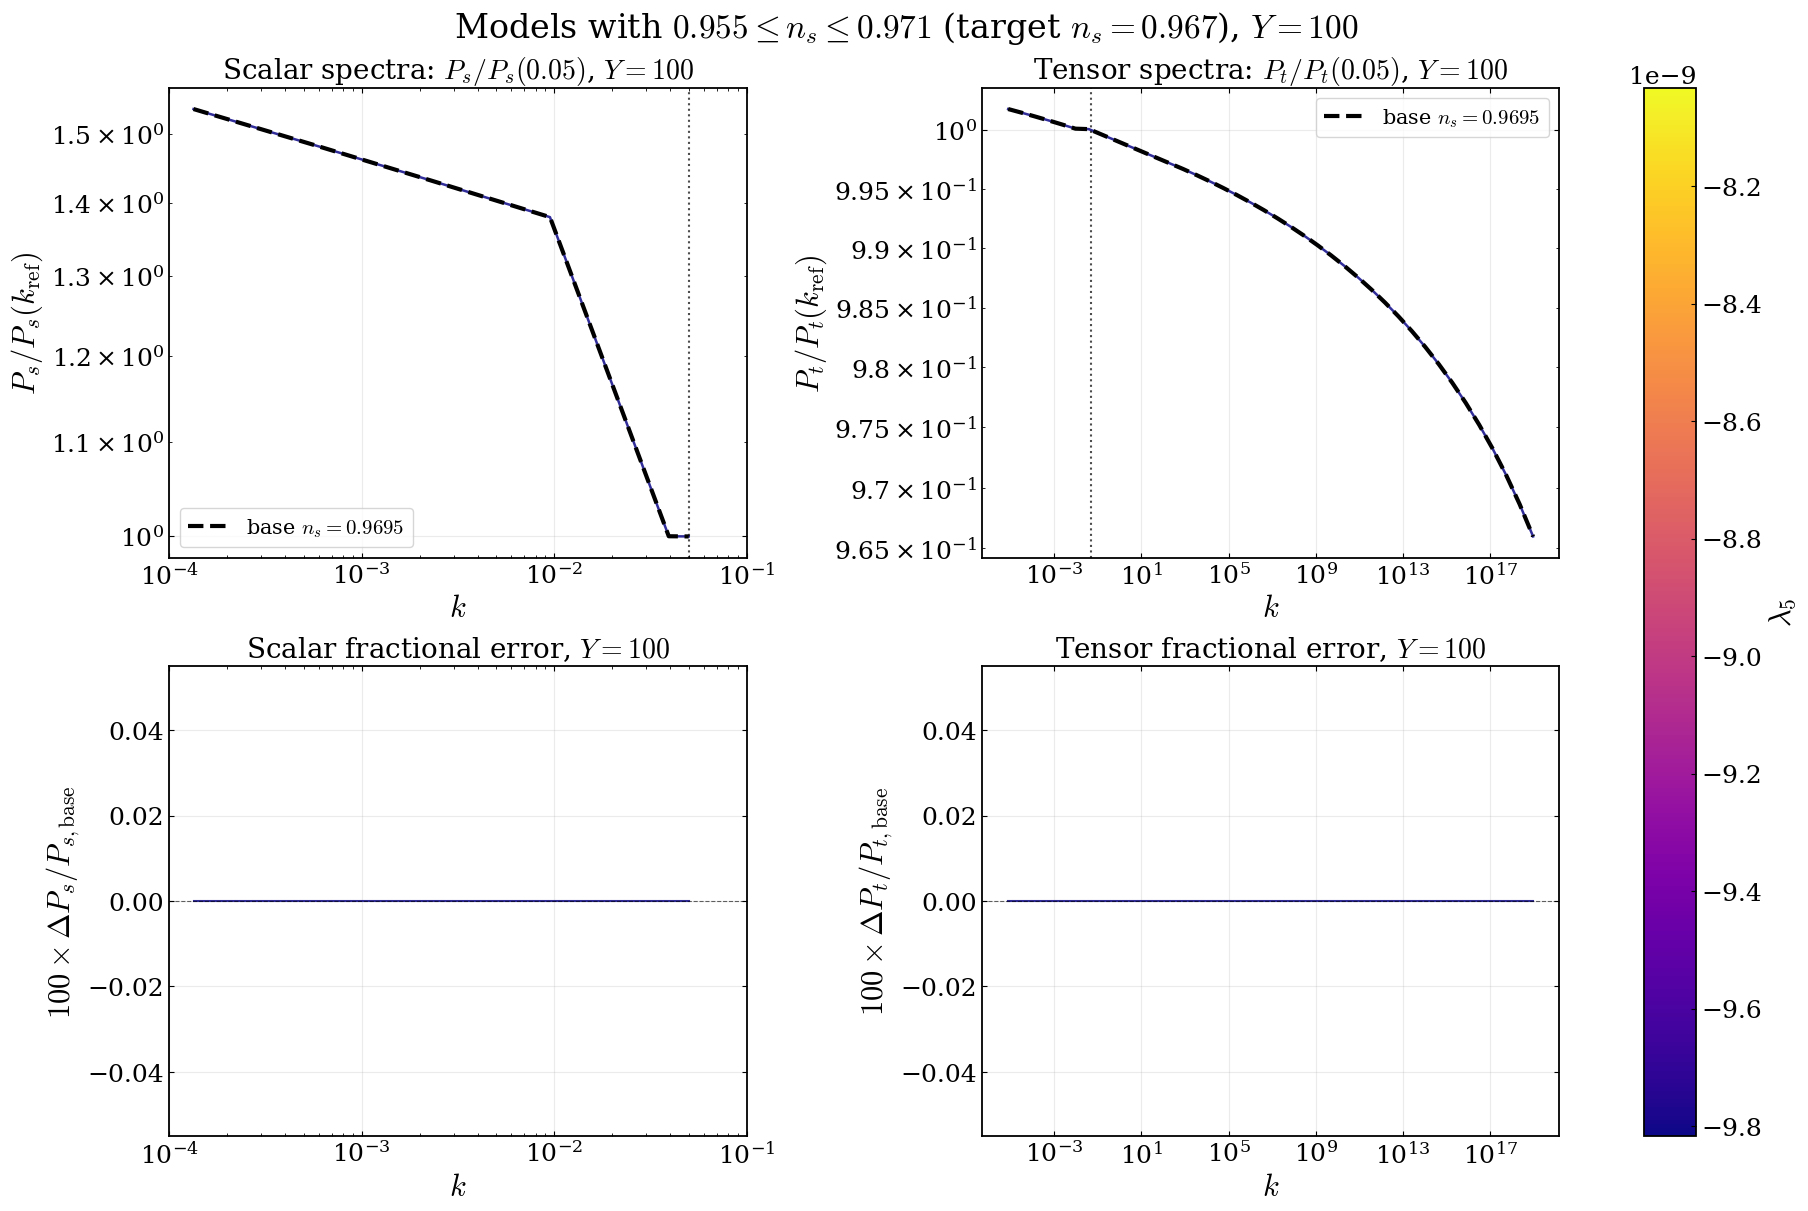

In [7]:
for Yval in [1, 3, 10, 50, 100]:
    stats, kept = plot_filtered_spectra_by_ns(
        NEQS=8,
        lamX_values=lam5_saved,
        baseX=LAM5_BASE,
        base_path_root=BASE_PATH_ROOT,
        Yval=Yval,
        k_min_scalar=1e-4,
        k_max_scalar=1e-1,
        show=True,
    )

All together:

In [10]:
def plot_Y_comparison_for_model(
    NEQS,
    lamX,
    base_path_root,
    Y_values=[1, 3, 10, 50, 100],
    Y_base=50,
    k_ref=0.05,
    k_min=None,
    k_max=None,
    save_name=None,
    show=True,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}_Y_variation",
        f"{scan_name}_{lamX:.10e}",
    )

    def load_spec(Yval):
        sfile = os.path.join(folder, f"spec_s_neqs{NEQS}_Y{Yval}.dat")
        tfile = os.path.join(folder, f"spec_t_neqs{NEQS}_Y{Yval}.dat")

        s = np.loadtxt(sfile)
        t = np.loadtxt(tfile)

        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)
        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at k_ref={x_ref}")

        return x, y / y_ref

    def frac_relative_to_base(k_base, P_base, k_cmp, P_cmp):
        k_base, P_base = prepare_increasing(k_base, P_base)
        k_cmp, P_cmp = prepare_increasing(k_cmp, P_cmp)

        xlo = max(k_base.min(), k_cmp.min())
        xhi = min(k_base.max(), k_cmp.max())

        if k_min is not None:
            xlo = max(xlo, k_min)
        if k_max is not None:
            xhi = min(xhi, k_max)

        mask = (k_base >= xlo) & (k_base <= xhi)
        k_use = k_base[mask]
        P_base_use = P_base[mask]

        if len(k_use) == 0:
            raise ValueError("No overlapping k range for fractional comparison.")

        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp)
        frac = (P_cmp_interp - P_base_use) / P_base_use

        return k_use, frac

    # Load baseline
    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_spec(Y_base)
    k_s_base, Ps_base = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

    ax_ps, ax_pt = axes[0]
    ax_dps, ax_dpt = axes[1]

    diff_rows = []

    for Yval in Y_values:
        k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_spec(Yval)

        k_s, Ps = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
        k_t, Pt = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

        label = f"Y={Yval}"

        if Yval == Y_base:
            lw = 3.0
            ls = "--"
            alpha = 1.0
        else:
            lw = 1.8
            ls = "-"
            alpha = 0.85

        ax_ps.loglog(k_s, Ps, lw=lw, ls=ls, alpha=alpha, label=label)
        ax_pt.loglog(k_t, Pt, lw=lw, ls=ls, alpha=alpha, label=label)

        if Yval != Y_base:
            k_dps, dps = frac_relative_to_base(k_s_base, Ps_base, k_s, Ps)
            k_dpt, dpt = frac_relative_to_base(k_t_base, Pt_base, k_t, Pt)

            ax_dps.semilogx(k_dps, 100.0 * dps, lw=1.8, label=label)
            ax_dpt.semilogx(k_dpt, 100.0 * dpt, lw=1.8, label=label)

            diff_rows.append({
                "Y": Yval,
                "mean_dPs_pct": 100.0 * np.nanmean(dps),
                "max_abs_dPs_pct": 100.0 * np.nanmax(np.abs(dps)),
                "mean_dPt_pct": 100.0 * np.nanmean(dpt),
                "max_abs_dPt_pct": 100.0 * np.nanmax(np.abs(dpt)),
            })
        else:
            diff_rows.append({
                "Y": Yval,
                "mean_dPs_pct": 0.0,
                "max_abs_dPs_pct": 0.0,
                "mean_dPt_pct": 0.0,
                "max_abs_dPt_pct": 0.0,
            })

    for ax in [ax_dps, ax_dpt]:
        ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.6)

    for ax in axes.ravel():
        ax.axvline(k_ref, color="black", ls=":", lw=1.0, alpha=0.7)
        ax.grid(True, alpha=0.25)
        ax.legend()

        if k_min is not None or k_max is not None:
            ax.set_xlim(k_min, k_max)

    ax_ps.set_title(rf"Scalar spectra normalized at $k={k_ref}$")
    ax_pt.set_title(rf"Tensor spectra normalized at $k={k_ref}$")
    ax_dps.set_title(rf"Scalar fractional difference relative to $Y={Y_base}$")
    ax_dpt.set_title(rf"Tensor fractional difference relative to $Y={Y_base}$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_dps.set_ylabel(rf"$100\times(P_s^Y-P_s^{{{Y_base}}})/P_s^{{{Y_base}}}$")
    ax_dpt.set_ylabel(rf"$100\times(P_t^Y-P_t^{{{Y_base}}})/P_t^{{{Y_base}}}$")

    for ax in axes[1]:
        ax.set_xlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$")

    fig.suptitle(
        rf"Y comparison for ${scan_symbol}={lamX:.3e}$",
        fontsize=22,
    )

    diff_df = pd.DataFrame(diff_rows)

    print(f"\n=== Percent differences relative to Y={Y_base} ===")
    print(diff_df.to_string(index=False))

    if save_name is None:
        save_name = f"Y_comparison_neqs{NEQS}_{scan_name}_{lamX:.10e}.png"

    # plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return diff_df


=== Percent differences relative to Y=50 ===
  Y  mean_dPs_pct  max_abs_dPs_pct  mean_dPt_pct  max_abs_dPt_pct
  1     -3.250739        14.574175     -0.000996         0.013792
  3      0.299937         1.425609      0.003021         0.039821
 10     -0.031863         0.154621      0.002366         0.034916
 50      0.000000         0.000000      0.000000         0.000000
100     86.546231       330.813697      1.166229         6.004748


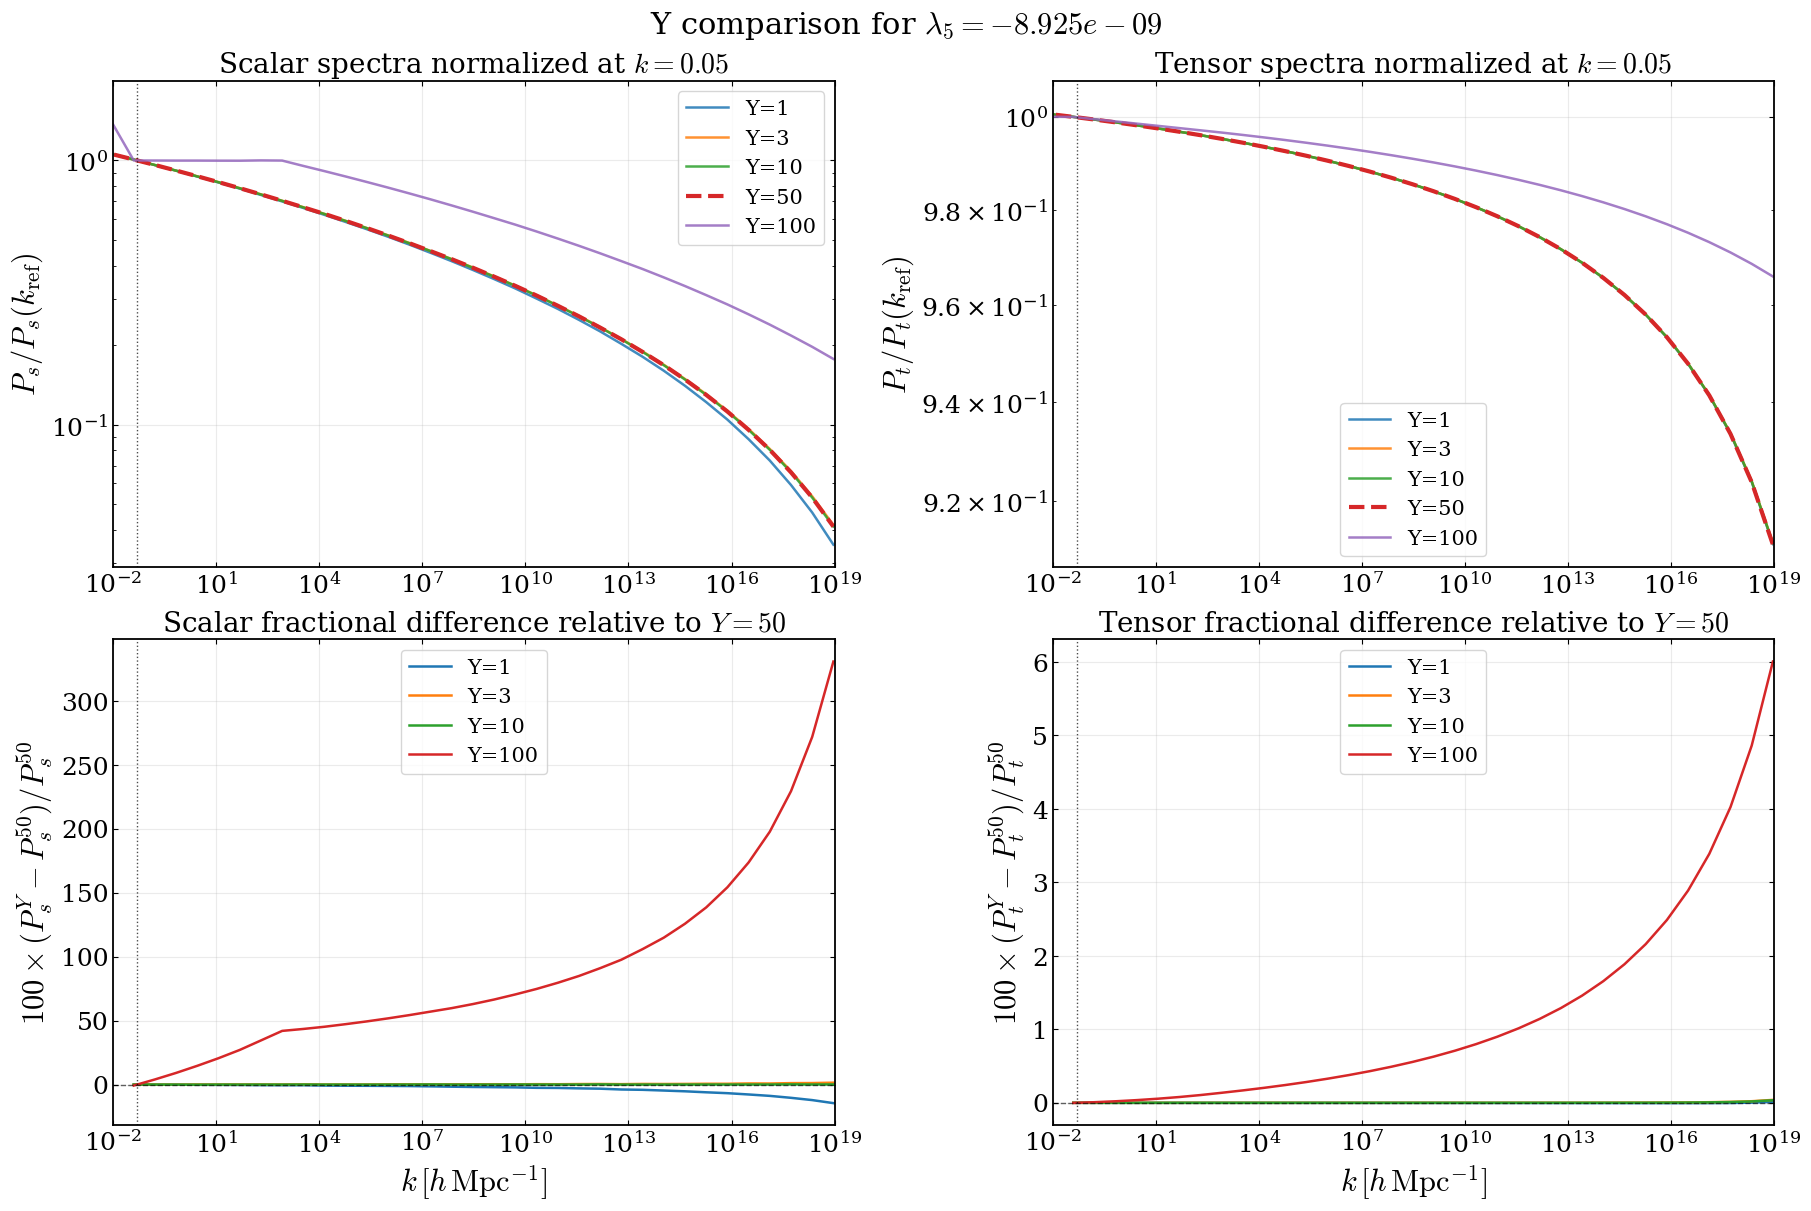

In [11]:
diff_df = plot_Y_comparison_for_model(
    NEQS=8,
    lamX=LAM5_BASE,
    base_path_root=BASE_PATH_ROOT,
    Y_values=[1, 3, 10, 50, 100],
    Y_base=50,
    k_ref=0.05,
    k_min=1e-2,
    k_max=1e19,
)

Tensor amp seems to be same for Y = 1, 3, 10, 50. Scalar amp seems close enough to 50 for Y = 10. But do we believe that is sufficient? That is another matter entirely. Do we believe that accuracy?? This would be maybe where Pyoscode would come in. it couldn't hurt to do this again but with Pyoscode??? It is expected that the more oscillations one has to do the worst your numerical integratioon method. Agreement with Y=50 is only showing internal convergence relative to RK not that it is absolute truth. Pyoscode would be that second check to see whether or not it is truly accurate. Something to think about.